# Automobile Data Analysis and Preprocessing  

---

This notebook is designed to analyze the **1985 Automobile Imports Database**, which consists of various attributes of different car models. We'll load the data, preprocess it, and perform **exploratory data analysis (EDA)** to prepare it for machine learning algorithms. The notebooks takes care of:

1️⃣ **Loading the Data**: We will load the dataset and add appropriate column headers for better readability.  
2️⃣ **Handling Missing Values**: Missing values will be imputed using the **median**, but we can experiment with other techniques such as the **mean** or predictive imputation.  
3️⃣ **Exploratory Data Analysis (EDA)**: Different plots that will give you a solid understanding of the dataset we are dealing with.

💡 Feel free to **experiment with different EDA techniques** and **add more visualizations** :)

### Importing Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PowerTransformer,RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from skopt import BayesSearchCV
import scipy.stats as stats

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_validate

from sklearn.decomposition import PCA

from skopt import BayesSearchCV

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_style('whitegrid')  
plt.rcParams['figure.figsize'] = (12, 8)

### Loading the Data

Based on the metadata in `imports-85.names`, we know this dataset has 26 attributes. Let's define the column names and load the data.

In [42]:
# Define column names from the metadata file
columns = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
           'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
           'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
           'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
           'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Load the data
data = pd.read_csv('../data/imports-85.data', header=None, names=columns)

# Display first few rows
data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [43]:
# Replace '?' with NaN
data = data.replace('?', np.nan)

# Check initial data types
print("Data types before conversion:")
print(data.dtypes)

Data types before conversion:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object


In [44]:
# Count missing values before any processing
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


### Preliminary Data Type Conversions

Before splitting, we need to convert string columns to numeric where appropriate.

In [45]:
# Numeric columns that need to be converted
numeric_cols = ['normalized-losses', 'wheel-base', 'length', 'width', 'height',
                'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Convert to numeric
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Check data types after conversion
print("Data types after conversion:")
print(data.dtypes)

Data types after conversion:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


### Train-Test Split

It's crucial to split the data into training and test sets before performing any further preprocessing or analysis to prevent data leakage.

In [46]:
# Define the target variable (assuming we're predicting price)
X = data.drop('price', axis=1)
y = data['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a full training dataset (including the target variable) for EDA
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (164, 25)
Testing set shape: (41, 25)


_________________

## Data Preprocessing

Now we'll preprocess the data, making sure to fit preprocessing operations only on the training set.

### Handling Missing Values

In [47]:
# Calculate percentage of missing values in training set
missing_percentage = train_data.isnull().sum() / len(train_data) * 100

# Create a dataframe to display columns with missing values
missing_data = pd.DataFrame({'Column': train_data.columns,
                            'Missing Value Count': train_data.isnull().sum(),
                            'Missing Percentage': missing_percentage})

# Sort by percentage of missing values
missing_data = missing_data.sort_values('Missing Percentage', ascending=False)
missing_data = missing_data[missing_data['Missing Value Count'] > 0]
missing_data

,Column,Missing Value Count,Missing Percentage
normalized-losses,normalized-losses,66,33.502538
stroke,stroke,36,18.274112
bore,bore,36,18.274112
price,price,35,17.766497
peak-rpm,peak-rpm,35,17.766497
num-of-doors,num-of-doors,35,17.766497
horsepower,horsepower,35,17.766497
engine-type,engine-type,33,16.751269
highway-mpg,highway-mpg,33,16.751269
city-mpg,city-mpg,33,16.751269


In [48]:
# Create a copy of numeric_cols without 'price' for imputation
# since price is our target variable and has been removed from X_train and X_test
numeric_features_for_imputation = [col for col in numeric_cols if col != 'price']

# Impute missing values based on training data only
# For numeric columns, use median
numeric_imputer = SimpleImputer(strategy='median')

X_train_numeric = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features_for_imputation]),
    columns=numeric_features_for_imputation,
    index=X_train.index
)

# Apply the SAME imputer to test set (using parameters learned from training)
X_test_numeric = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features_for_imputation]), 
    columns=numeric_features_for_imputation, 
    index=X_test.index
)

# For categorical columns with missing values, use most frequent value
cat_cols_with_missing = ['num-of-doors']
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit on training data
X_train_cat_missing = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols_with_missing]), 
    columns=cat_cols_with_missing, 
    index=X_train.index
)

# Transform test data
X_test_cat_missing = pd.DataFrame(
    cat_imputer.transform(X_test[cat_cols_with_missing]), 
    columns=cat_cols_with_missing, 
    index=X_test.index
)

# Update the imputed columns in our datasets
X_train[numeric_features_for_imputation] = X_train_numeric
X_test[numeric_features_for_imputation] = X_test_numeric
X_train[cat_cols_with_missing] = X_train_cat_missing
X_test[cat_cols_with_missing] = X_test_cat_missing

# Update training data for EDA
train_data[numeric_features_for_imputation] = X_train_numeric
train_data[cat_cols_with_missing] = X_train_cat_missing

# Verify no missing values remain
print("Missing values after imputation in training set:", X_train.isnull().sum().sum())
print("Missing values after imputation in test set:", X_test.isnull().sum().sum())
print("Missing values in y_train", y_train.isnull().sum().sum())
print("Missing values in y_test", y_test.isnull().sum().sum())

#Dropping the nan rows in the y and the corresponding x
X_train = X_train[y_train.notna()]
y_train = y_train.dropna()

X_test = X_test[y_test.notna()]
y_test = y_test.dropna()

#Final verification

print("Missing values after imputation in training set:", X_train.isnull().sum().sum())
print("Missing values after imputation in test set:", X_test.isnull().sum().sum())
print("Missing values in y_train", y_train.isnull().sum().sum())
print("Missing values in y_test", y_test.isnull().sum().sum())

Missing values after imputation in training set: 0
Missing values after imputation in test set: 0
Missing values in y_train 2
Missing values in y_test 2
Missing values after imputation in training set: 0
Missing values after imputation in test set: 0
Missing values in y_train 0
Missing values in y_test 0


_________

## Exploratory Data Analysis (EDA)

Now we'll perform EDA on the **training data only** to understand the relationships between variables without leaking information from the test set.

### Distribution of Continuous Variables

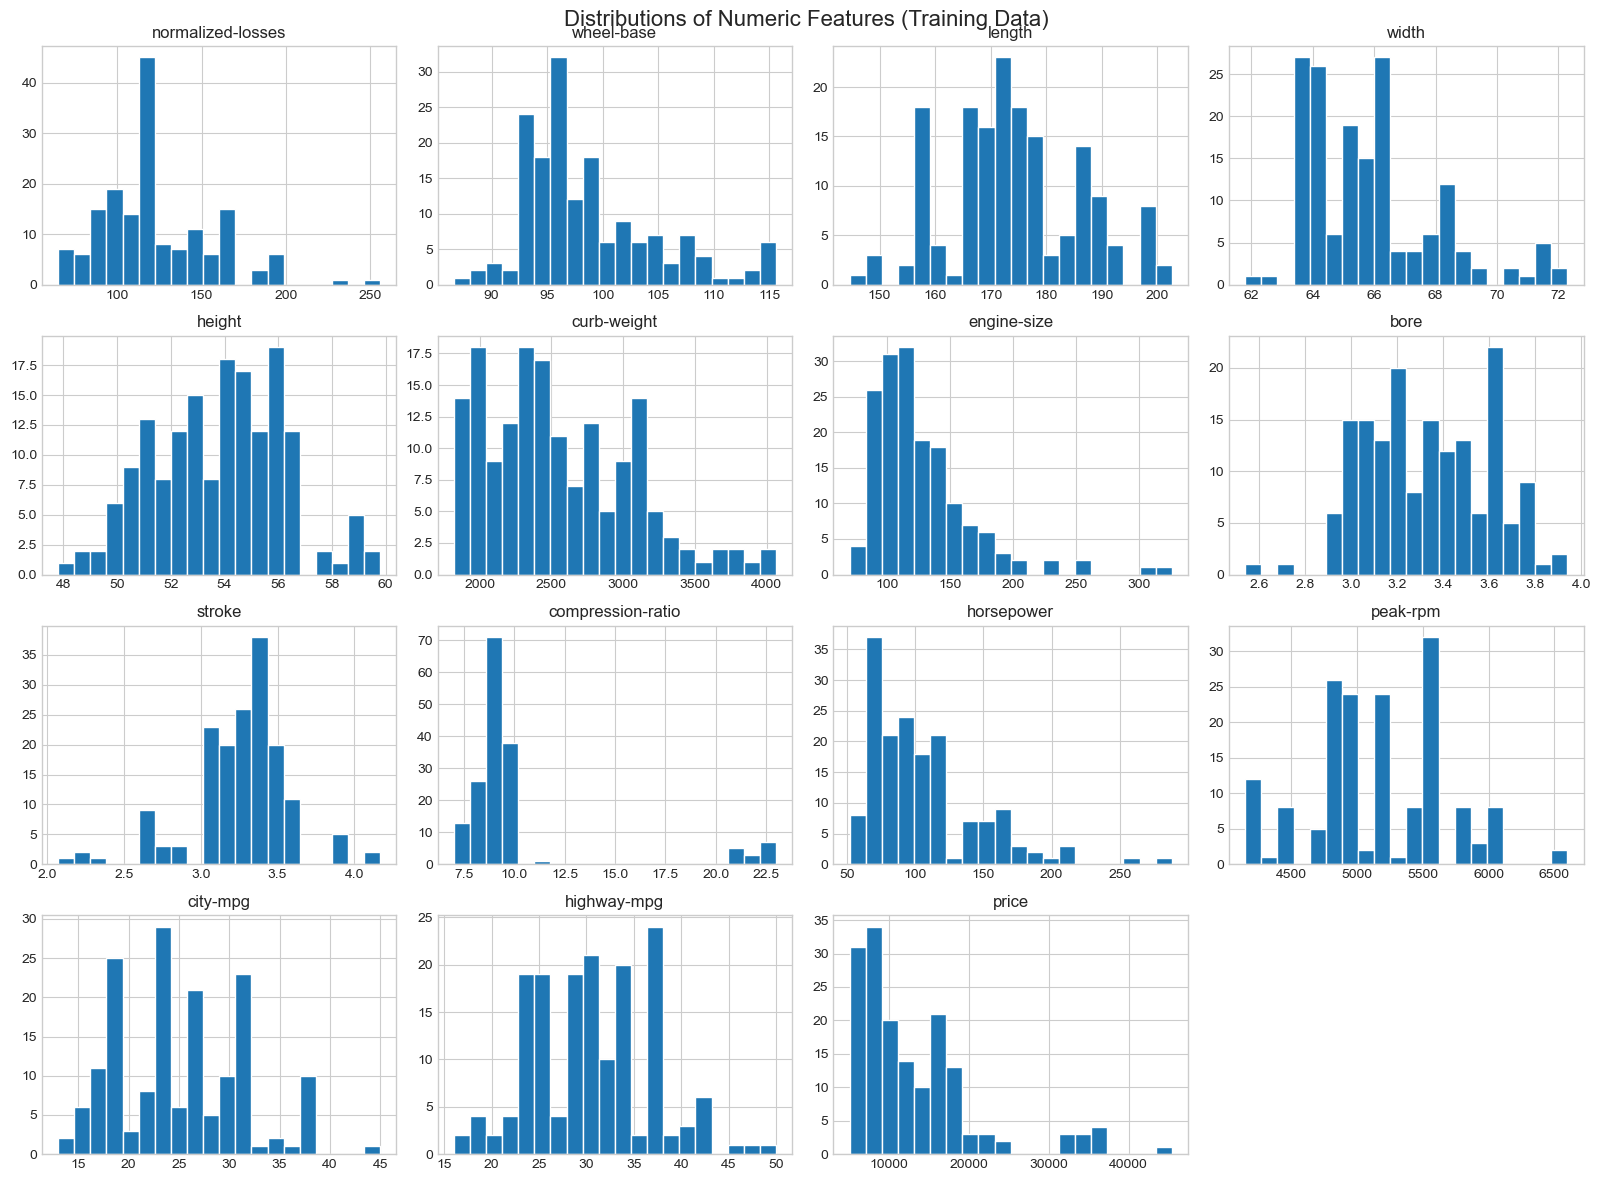

In [49]:
# Use numeric features for imputation plus 'price' for the histograms
numeric_cols_for_eda = numeric_features_for_imputation + ['price']

# Histogram of all numeric variables (training data only)
train_data[numeric_cols_for_eda].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.suptitle("Distributions of Numeric Features (Training Data)", fontsize=16)
plt.subplots_adjust(top=0.95)
plt.show()

### Car Makes Analysis

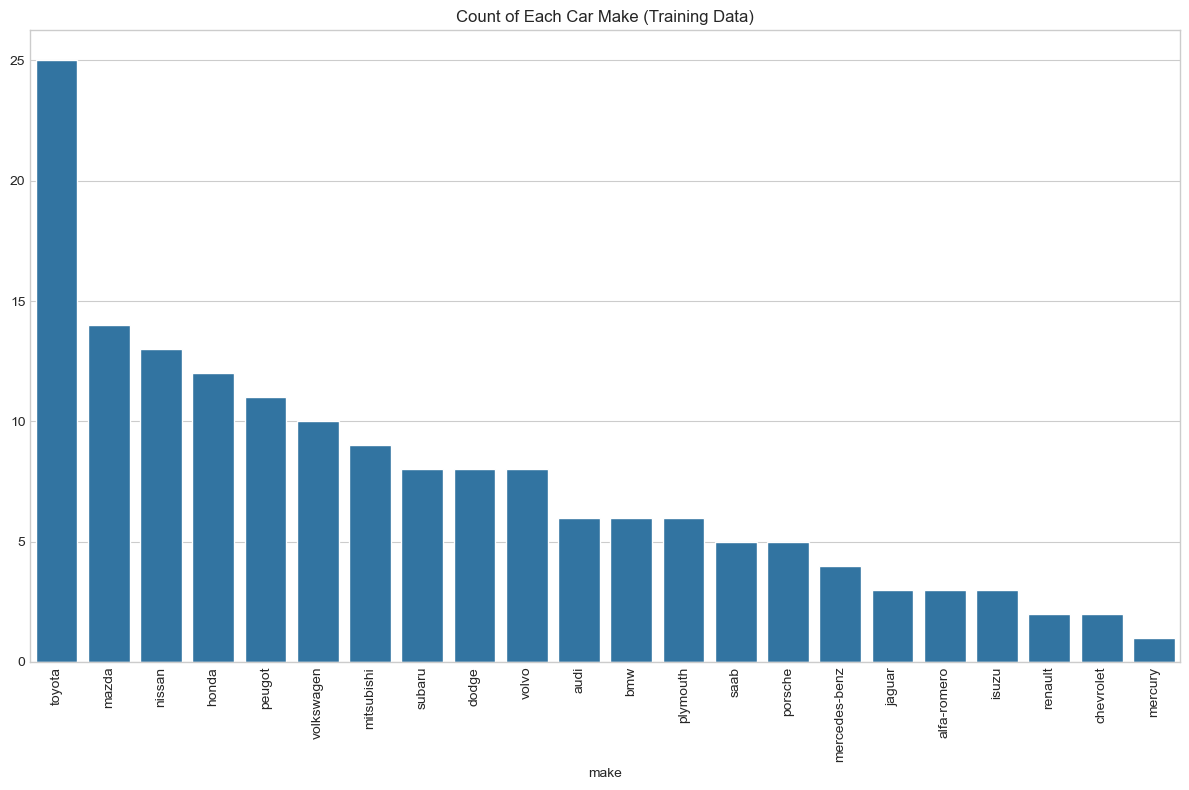

In [50]:
# Count of each car make (training data only)
plt.figure(figsize=(12, 8))
count_make = train_data['make'].value_counts()
sns.barplot(x=count_make.index, y=count_make.values)
plt.title('Count of Each Car Make (Training Data)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

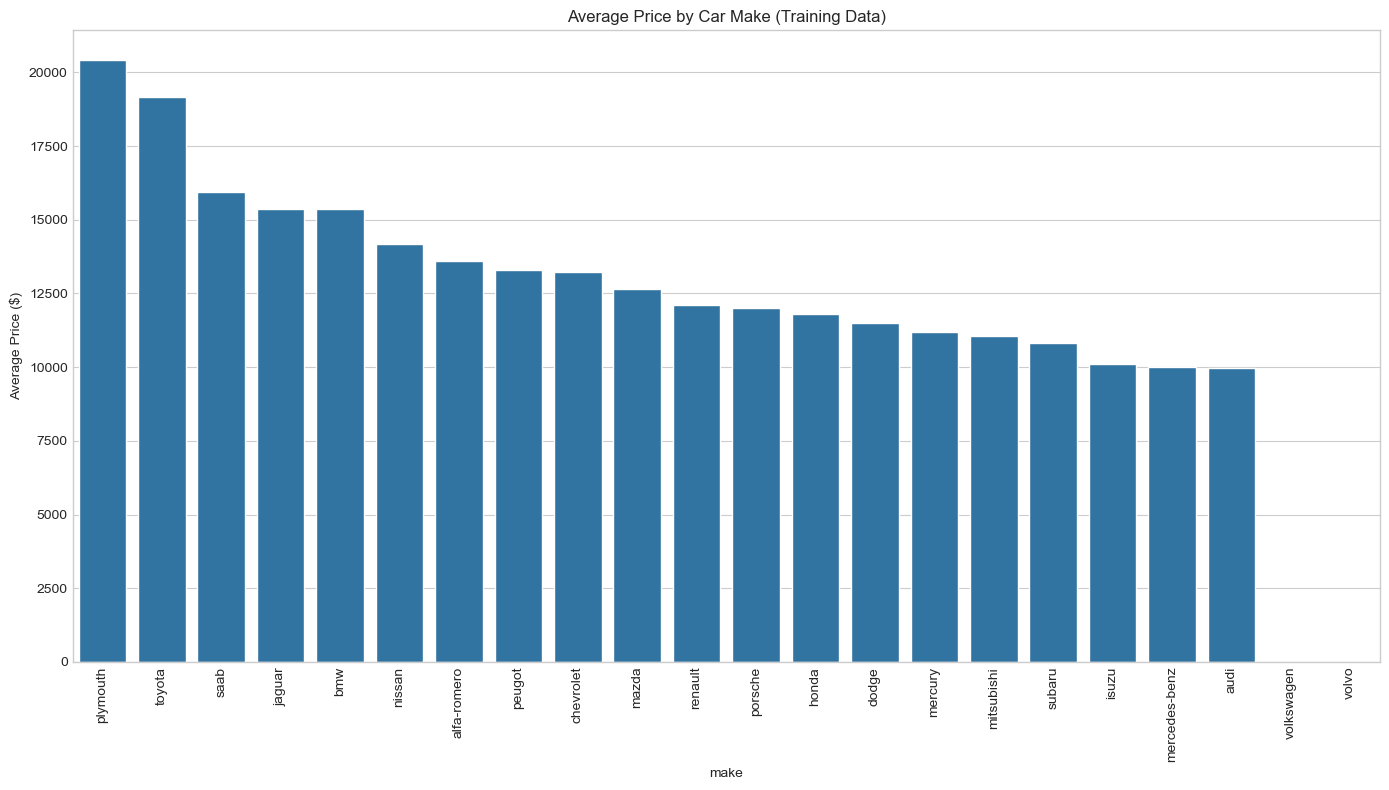

In [51]:
# Average price by make (training data only)
plt.figure(figsize=(14, 8))
avg_price = train_data.groupby('make')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title('Average Price by Car Make (Training Data)')
plt.xticks(rotation=90)
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

### Price Analysis

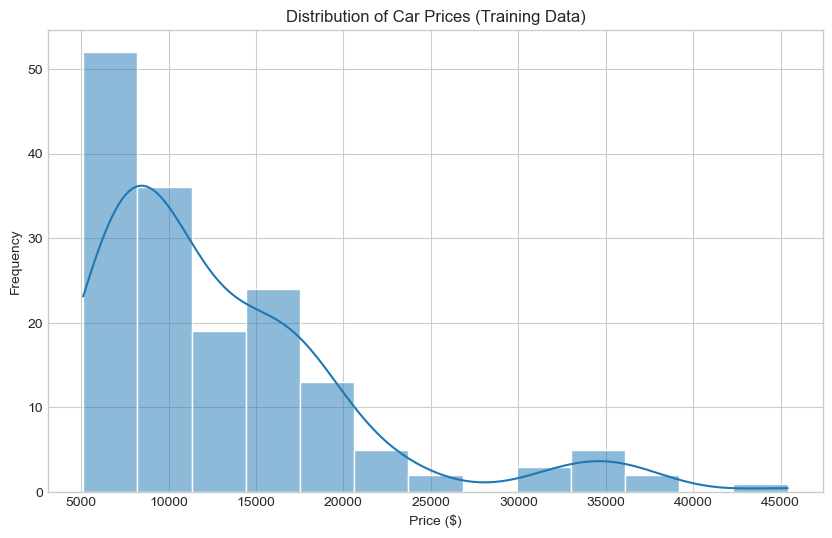

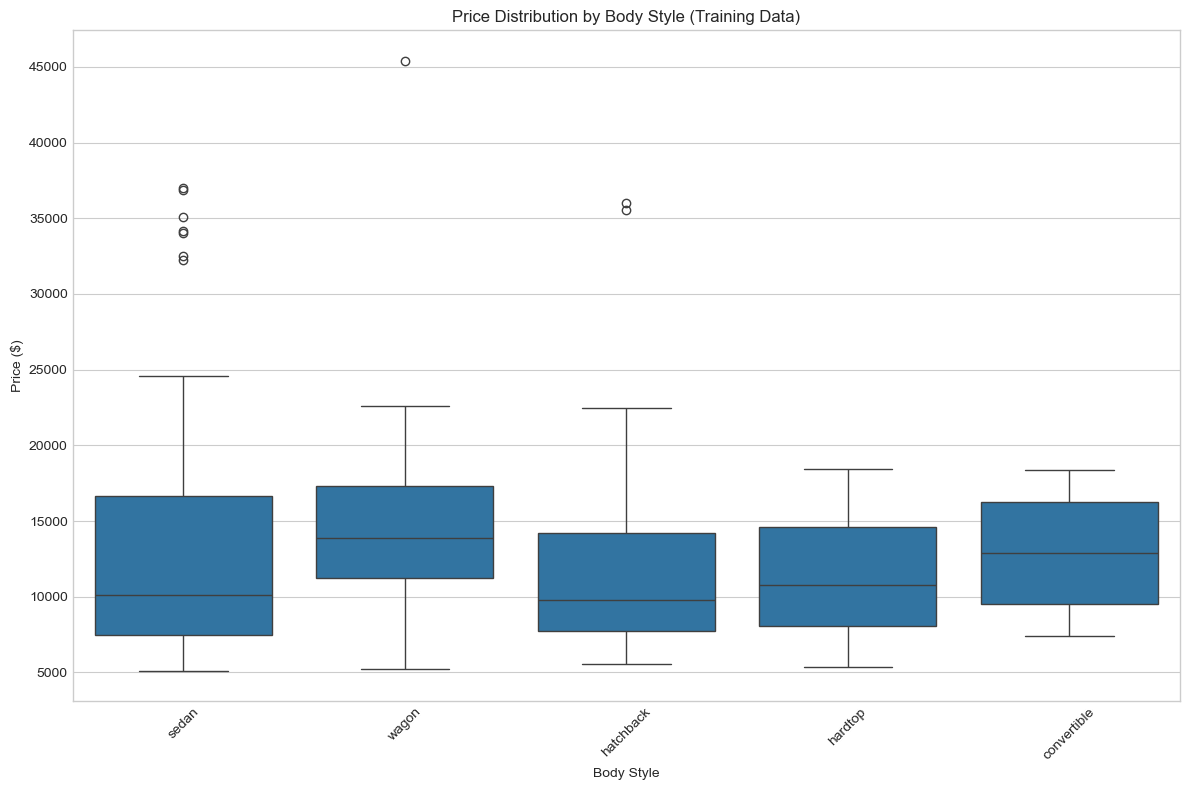

In [52]:
# Distribution of Price (training data only)
plt.figure(figsize=(10, 6))
sns.histplot(train_data['price'], kde=True)
plt.title('Distribution of Car Prices (Training Data)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Box plot of price by body style (training data only)
plt.figure(figsize=(12, 8))
sns.boxplot(x='body-style', y='price', data=train_data)
plt.title('Price Distribution by Body Style (Training Data)')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Analysis

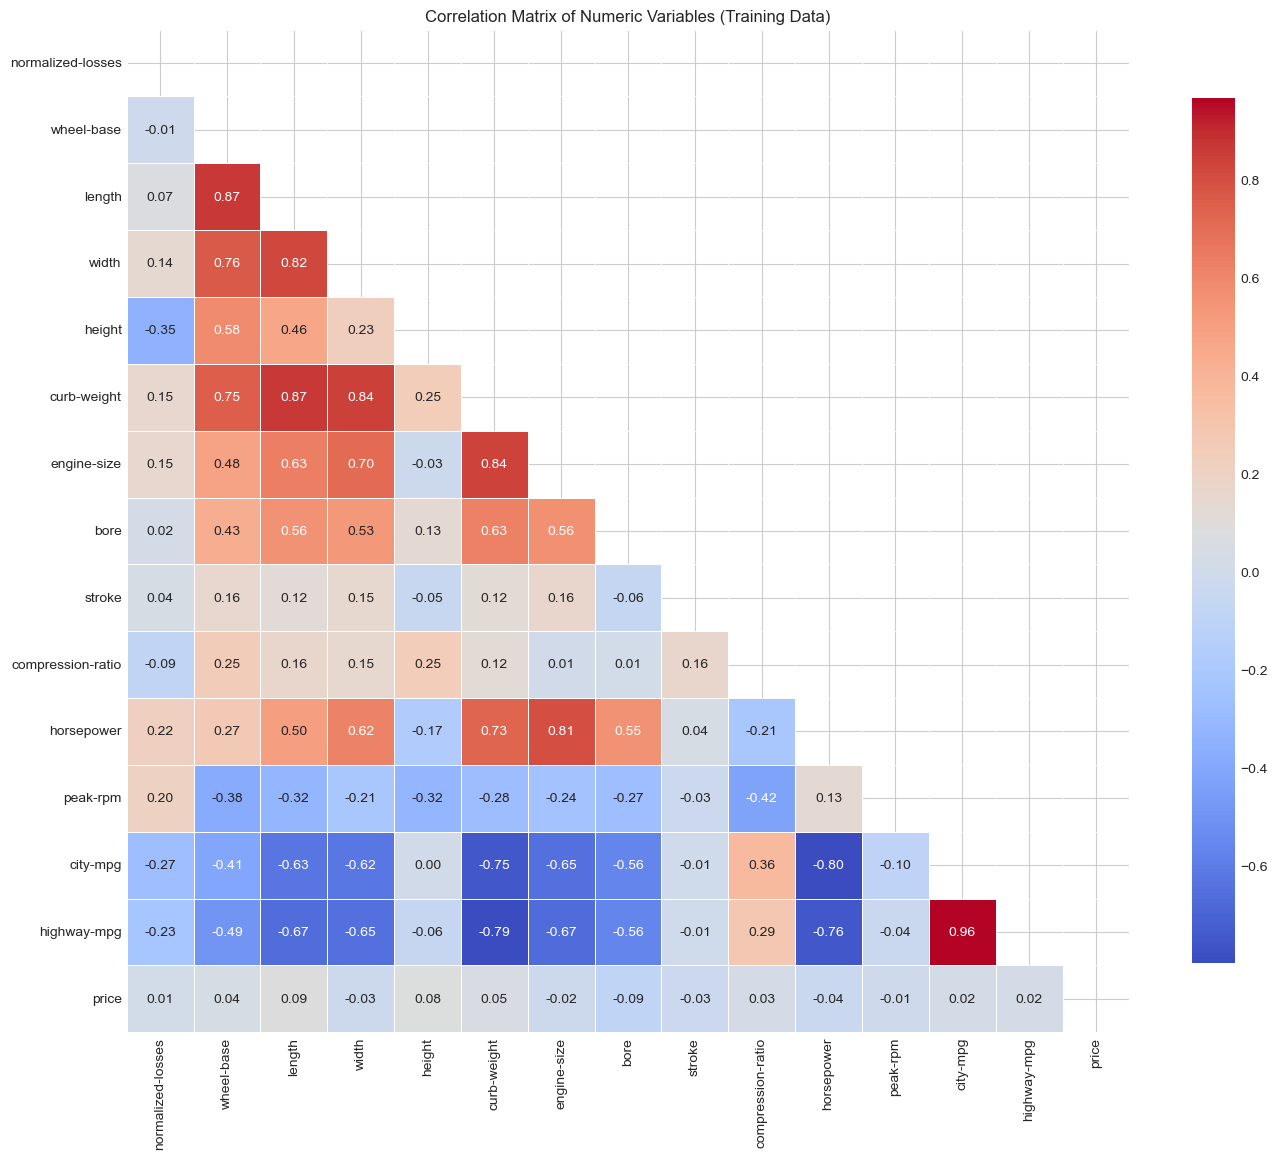

In [53]:
# Calculate correlation matrix for numeric variables (training data only)
corr_matrix = train_data[numeric_cols_for_eda].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Numeric Variables (Training Data)')
plt.tight_layout()
plt.show()

### Key Feature Relationships

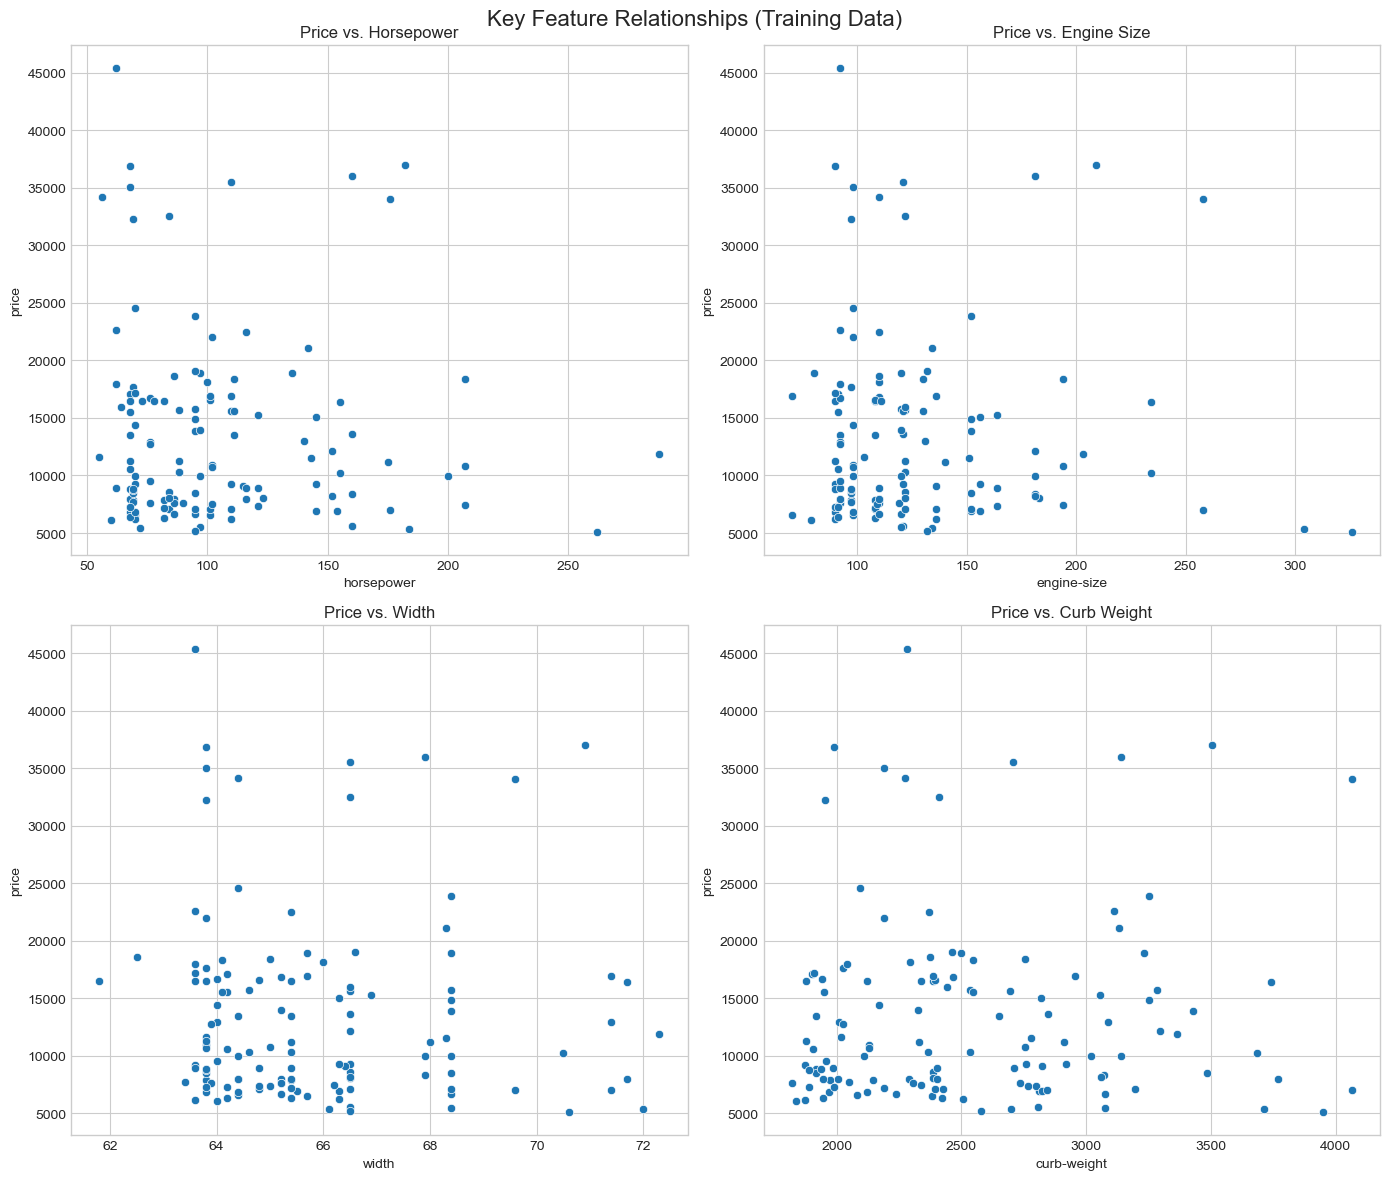

In [54]:
# Scatter plots for key feature relationships (training data only)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Price vs. horsepower
sns.scatterplot(x='horsepower', y='price', data=train_data, ax=axes[0, 0])
axes[0, 0].set_title('Price vs. Horsepower')

# Price vs. engine-size
sns.scatterplot(x='engine-size', y='price', data=train_data, ax=axes[0, 1])
axes[0, 1].set_title('Price vs. Engine Size')

# Price vs. width
sns.scatterplot(x='width', y='price', data=train_data, ax=axes[1, 0])
axes[1, 0].set_title('Price vs. Width')

# Price vs. curb-weight
sns.scatterplot(x='curb-weight', y='price', data=train_data, ax=axes[1, 1])
axes[1, 1].set_title('Price vs. Curb Weight')

plt.suptitle("Key Feature Relationships (Training Data)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Specific Analysis of Width and Horsepower

Based on the 'misc' file, there seems to be a special interest in the relationship between width and horsepower.

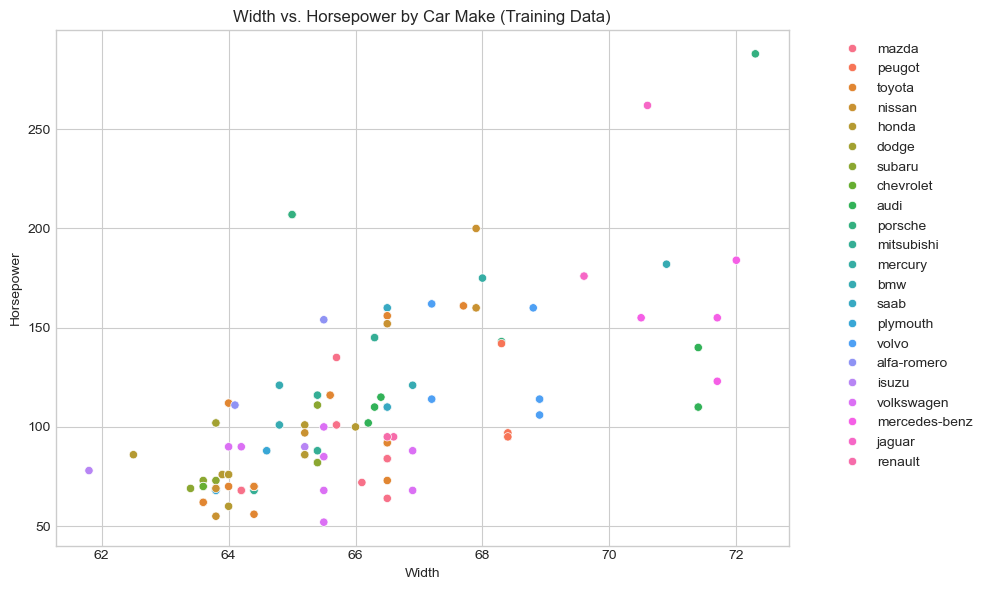

In [55]:
# Scatter plot with width and horsepower (training data only)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='width', y='horsepower', data=train_data, hue='make')
plt.title('Width vs. Horsepower by Car Make (Training Data)')
plt.xlabel('Width')
plt.ylabel('Horsepower')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

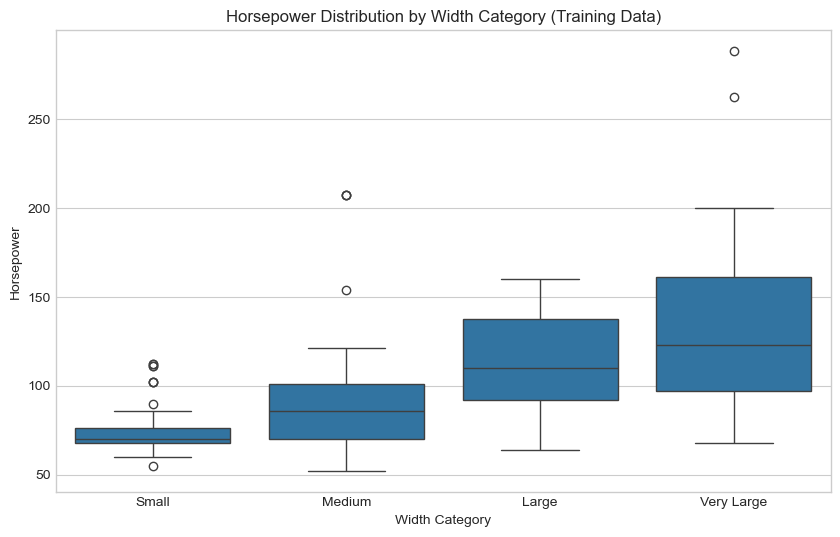

In [56]:
# Compare horsepower across different width ranges (training data only)
train_data['width_category'] = pd.qcut(train_data['width'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='width_category', y='horsepower', data=train_data)
plt.title('Horsepower Distribution by Width Category (Training Data)')
plt.xlabel('Width Category')
plt.ylabel('Horsepower')
plt.show()

## Feature Engineering

We'll create new features based on our understanding of the data, keeping the training/test separation intact.

In [57]:
# Create feature engineering functions to apply to both training and test sets
def engineer_features(df):
    """Apply feature engineering to the dataset"""
    # Create a power-to-weight ratio feature
    df['power_to_weight'] = df['horsepower'] / df['curb-weight']
    
    # Create a feature for engine size per cylinder
    # First, convert num-of-cylinders to numeric
    cylinder_map = {
        'two': 2,
        'three': 3,
        'four': 4,
        'five': 5,
        'six': 6,
        'eight': 8,
        'twelve': 12
    }
    df['num_cylinders'] = df['num-of-cylinders'].map(cylinder_map)
    df['engine_size_per_cylinder'] = df['engine-size'] / df['num_cylinders']
    
    # Create fuel efficiency feature (combined MPG)
    df['combined_mpg'] = (df['city-mpg'] + df['highway-mpg']) / 2
    
    return df

# Apply feature engineering to both sets
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

# Update training data for continued analysis
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

# Display new features
train_data[['power_to_weight', 'engine_size_per_cylinder', 'combined_mpg']].describe()

,power_to_weight,engine_size_per_cylinder,combined_mpg
count,162.000000,162.000000,162.000000
mean,0.040079,28.794856,27.777778
std,0.009358,4.934102,6.188800
min,0.019936,19.750000,15.000000
25%,0.034346,24.500000,22.125000
50%,0.037961,27.500000,27.000000
75%,0.043848,30.500000,32.000000
max,0.075109,43.000000,47.500000


## Preparing for Machine Learning

Now we'll prepare our data for machine learning by encoding categorical variables and scaling numeric features, maintaining our train/test separation.

In [58]:
# Identify feature types
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Remove width_category created during EDA if it exists
if 'width_category' in X_train.columns:
    X_train = X_train.drop('width_category', axis=1)
if 'width_category' in X_test.columns:
    X_test = X_test.drop('width_category', axis=1)

# Update feature lists if needed
if 'width_category' in numeric_features:
    numeric_features.remove('width_category')
if 'width_category' in categorical_features:
    categorical_features.remove('width_category')

In [59]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', pd.get_dummies)
])

# Apply one-hot encoding to categorical features
X_train_cat = pd.get_dummies(X_train[categorical_features], drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_features], drop_first=True)

# Ensure test set has the same columns as train set
missing_cols = set(X_train_cat.columns) - set(X_test_cat.columns)
for col in missing_cols:
    X_test_cat[col] = 0
X_test_cat = X_test_cat[X_train_cat.columns]

# Scale numeric features
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[numeric_features]), 
                         columns=numeric_features, 
                         index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[numeric_features]), 
                        columns=numeric_features, 
                        index=X_test.index)


# Scale target variable
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))



# Convert scaled y values back to pandas Series/DataFrame for consistency
y_train_scaled = pd.DataFrame(y_train_scaled, index=y_train.index, columns=['price'])
y_test_scaled = pd.DataFrame(y_test_scaled, index=y_test.index, columns=['price'])

# Combine processed features
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")

Processed training data shape: (162, 67)
Processed test data shape: (39, 67)


In [60]:
# View sample of processed data
X_train_processed.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_six,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
66,-0.721994,-0.145503,1.027648,0.063977,0.098189,0.264626,0.284858,0.195626,0.420606,1.201459,...,False,False,False,False,False,True,False,False,False,False
111,-0.721994,1.155615,1.529494,1.036401,1.213595,1.195688,1.024898,-0.154003,0.533730,-3.351254,...,False,False,False,False,False,False,False,True,False,False
153,-0.721994,-1.386103,-0.511346,-0.376523,-1.114208,2.167232,-0.543987,-0.853261,-1.012294,-0.713820,...,False,False,False,True,False,False,False,False,False,False
96,0.079123,-0.024468,-0.712084,-0.742222,-1.017216,0.305107,-1.153780,-0.728394,-0.635215,0.102528,...,False,False,False,True,False,False,False,False,False,False
38,-0.721994,-0.508605,-0.377520,-0.559373,-0.338274,-0.180665,-0.526226,-0.403738,-0.635215,1.013071,...,False,False,False,False,False,False,False,False,False,False


Non scalled data

In [61]:
X_train_processed_not_stand = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
X_test_processed_not_stand = pd.concat([X_test[numeric_features], X_test_cat], axis=1)

X_test_processed_not_stand.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_six,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
15,0,118.0,103.5,189.0,66.9,55.7,3230.0,209.0,3.62,3.39,...,True,0,False,False,False,False,0,True,False,0
100,0,106.0,97.2,173.4,65.2,54.7,2302.0,120.0,3.33,3.47,...,False,0,False,True,False,False,0,False,False,0
132,3,150.0,99.1,186.6,66.5,56.1,2658.0,121.0,3.54,3.07,...,False,0,False,False,False,False,0,True,False,0
68,-1,93.0,110.0,190.9,70.3,58.7,3750.0,183.0,3.58,3.64,...,False,0,False,False,False,True,0,False,False,0
95,1,128.0,94.5,165.6,63.8,53.3,2028.0,97.0,3.15,3.29,...,False,0,False,True,False,False,0,False,False,0


___________________

# Training the models

#### Preparing the data

In [62]:
#The no
X_train_original_scale = X_train_processed_not_stand.reset_index(drop=True)
y_train_original_scale = y_train.reset_index(drop=True)

X_test_original_scale = X_test_processed_not_stand.reset_index(drop=True)
y_test_original_scale = y_test.reset_index(drop=True)

print(y_test_original_scale)

X_train = X_train_processed.reset_index(drop=True)
y_train = y_train_scaled.reset_index(drop=True)

X_test = X_test_processed.reset_index(drop=True)
y_test = y_test_scaled.reset_index(drop=True)

0     30760.0
1      9549.0
2     11850.0
3     28248.0
4      7799.0
5      7788.0
6      9258.0
7     10198.0
8      7775.0
9     13295.0
10     8238.0
11    18280.0
12     9988.0
13    40960.0
14     6488.0
15     5151.0
16    12629.0
17     8189.0
18     9960.0
19     8495.0
20    13499.0
21     8249.0
22     6479.0
23     6692.0
24    41315.0
25     9639.0
26    13415.0
27     7999.0
28    12940.0
29    25552.0
30     6229.0
31     7898.0
32    21485.0
33     7689.0
34    28176.0
35    11259.0
36    10945.0
37    14489.0
38     7463.0
Name: price, dtype: float64


#### Utility functions

In [63]:
def regression_report(predicted, true):
    mean_squared_error_value = mean_squared_error(true, predicted)
    mean_absolute_error_value = mean_absolute_error(true, predicted)
    r2_score_value = r2_score(true, predicted)
    root_mean_squared_error_value = root_mean_squared_error(true, predicted)

    print("="*50)
    print("       Regression performance report" )
    print("="*50)
    print(
    "   Mean squared error: ",  np.round(mean_squared_error_value, 3), "\n"
    "   Mean absolute error:",  np.round(mean_absolute_error_value, 3), "\n"
    "   Root mean squared error:",             np.round(root_mean_squared_error_value, 3), "\n"
    "   R2 score:",             np.round(r2_score_value, 3)
    )
    print("="*50)


In [64]:
def plot_actual_predicted(true, predicted):
    true = np.ravel(true)
    predicted = np.ravel(predicted)

    plt.figure(figsize=(8,6))

    sns.scatterplot(x=true, y=predicted, alpha=0.7, edgecolors='k', label="Predictions")

    min_value, max_value = min(true.min(), predicted.min()), max(true.max(), predicted.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="purple", linestyle='--', label="y = x")

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("Actual vs Predicted values")
    plt.legend()
    plt.grid(True)


In [65]:
def histogram_residuals(true, predicted):
    residuals = true - predicted
    
    
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, bins=10, kde=True, color='blue') 
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Histogram of Residuals")
    plt.grid(True)
    plt.show()

In [66]:
def plot_qq(residuals):
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title("QQ Plot of Residuals")
    plt.grid(True)
    plt.show()


______

## Knn regressor

#### Basic training

In [27]:
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X_train, y_train)

KNeighborsRegressor()

#### Prediction and accuracy

In [28]:
knn_predict1 = knn_regressor.predict(X_test)

regression_report(knn_predict1, y_test)

       Regression performance report
   Mean squared error:  0.429 
   Mean absolute error: 0.384 
   Root mean squared error: 0.655 
   R2 score: 0.695


#### Visualization of the regression

* First let's get the prediction in the non scaled format, so that we get plots with meaning and easily interpretable

In [29]:
knn_predict1_not_scaled = scaler_y.inverse_transform(knn_predict1.reshape(-1, 1)).flatten()

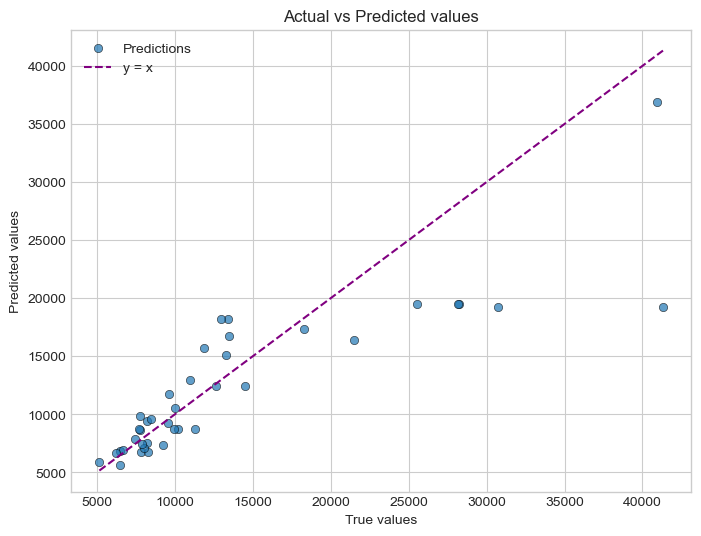

In [30]:
plot_actual_predicted(y_test_original_scale, knn_predict1_not_scaled)

We notice that the points somehow follow a straight line but there is some deviation.

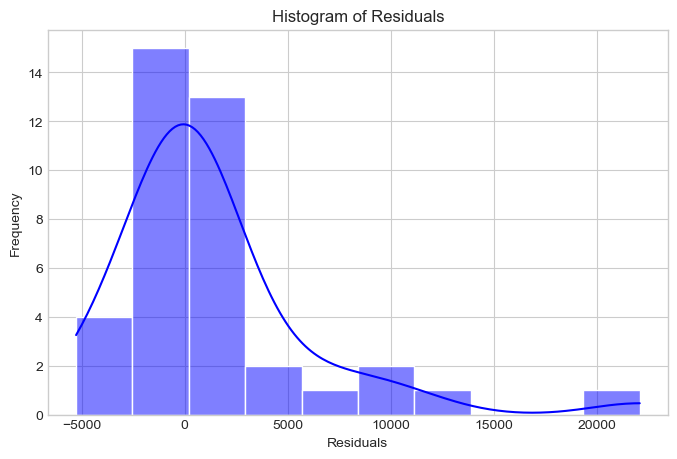

In [31]:
histogram_residuals(y_test_original_scale, knn_predict1_not_scaled)

 The residuals appear to be positively skewed

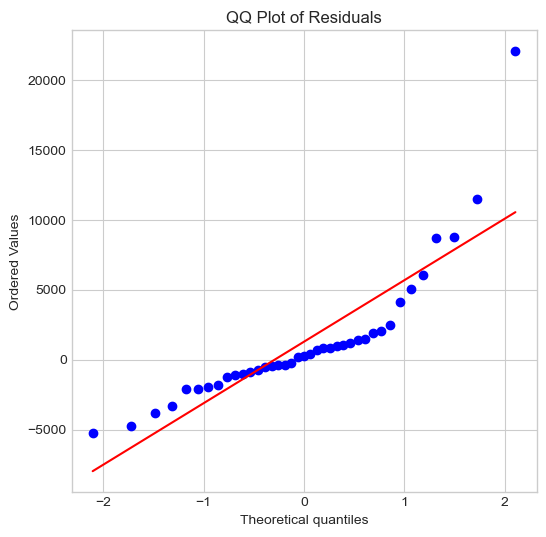

In [32]:
residuals = y_test_original_scale.to_numpy().flatten() - knn_predict1_not_scaled.flatten()

plot_qq(residuals)

The qq plot suggests that the points somehow follow the straight line, but there is a clear diviation which means the residuals are not normally distributed so the model didn't capture all the information.

#### Let's do some hyperparameter tuning using bayesian search to find the best setup

In [33]:
from skopt.space import Integer

search_space = {
    'n_neighbors': Integer(1, 50),  
    'weights': ['distance'],   #because of the presence of outliers let's choose weighted knn
    'metric': ['euclidean', 'manhattan'], 
}


In [ ]:
bayes_search = BayesSearchCV(
    knn_regressor,
    search_space,
    n_iter=20,  
    cv=5, 
    scoring='neg_mean_absolute_error',  
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

bayes_search.fit(X_train, y_train)

print("Best Parameters setup:", bayes_search.best_params_)

c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 42, 'distance']
  warnings.warn(
c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 7, 'distance']
  warnings.warn(
c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 7, 'distance']
  warnings.warn(


Best Parameters setup: OrderedDict({'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'})


From this we see that the best parameters are:  
Distance = manhattan    
k = 4   
weights = distance    

Let's build our knn regressor based on this

In [34]:
knn_regressor2 = KNeighborsRegressor(n_neighbors=4, metric="manhattan",weights="distance")
knn_regressor2.fit(X_train, y_train)

KNeighborsRegressor(metric='manhattan', n_neighbors=4, weights='distance')

#### Prediction and report

In [35]:
knn_predict2 = knn_regressor2.predict(X_test)

regression_report(knn_predict2, y_test)

       Regression performance report
   Mean squared error:  0.21 
   Mean absolute error: 0.26 
   Root mean squared error: 0.458 
   R2 score: 0.851


#### Visualization of the regression 

* Getting the non scaled prediction for better visualization & interpretability

In [36]:
knn_predict2_not_scaled = scaler_y.inverse_transform(knn_predict2.reshape(-1, 1)).flatten()

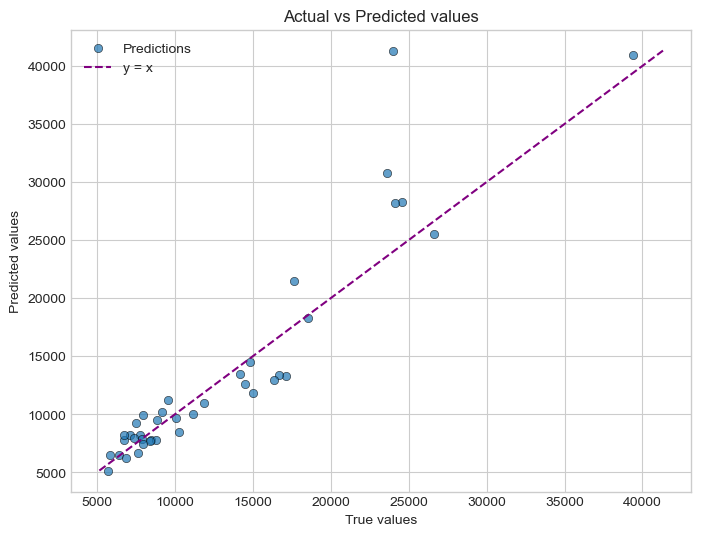

In [37]:
plot_actual_predicted(knn_predict2_not_scaled, y_test_original_scale)

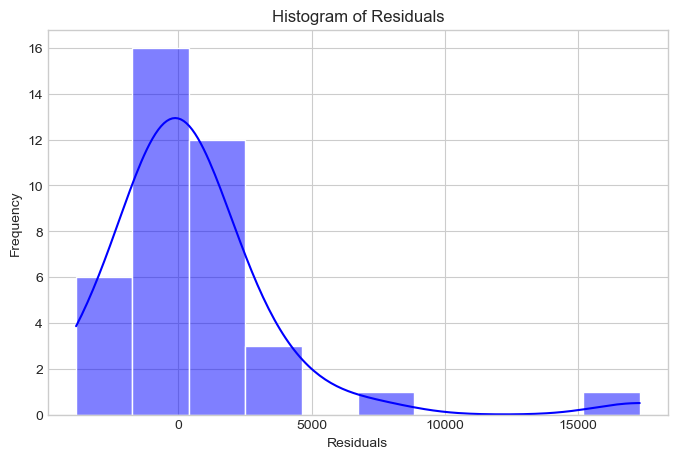

In [38]:
histogram_residuals(y_test_original_scale, knn_predict2_not_scaled)

 The residuals are still positively skewed

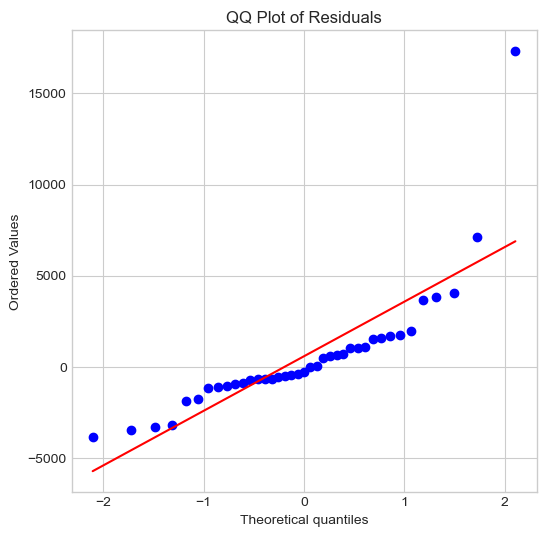

In [39]:
residuals = y_test_original_scale.to_numpy().flatten() - knn_predict2_not_scaled

plot_qq(residuals)

The residuals somehow follow the straight line, but the diviation is still there. Along with the extreme outlier at the top that is not captured by the regressor.

Cross validation

In [40]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer

cv = KFold(n_splits=10, shuffle=True, random_state=42)

# scoring metrics
scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'MSE':make_scorer(mean_squared_error),
    'RMSE':make_scorer(root_mean_squared_error),
    'R2': 'r2'
}

results = cross_validate(knn_regressor2, X_train, y_train, cv=cv, scoring=scoring)

#results
print(f"Test R²: {np.mean(results['test_R2']):.3f} (±{np.std(results['test_R2']):.3f})")
print(f"Test MAE: {np.mean(results['test_MAE']):.3f} (±{np.std(results['test_MAE']):.3f})")
print(f"Test MSE: {np.mean(results['test_MSE']):.3f} (±{np.std(results['test_MSE']):.3f})")
print(f"Test RMSE: {np.mean(results['test_RMSE']):.3f} (±{np.std(results['test_RMSE']):.3f})")



Test R²: 0.832 (±0.118)
Test MAE: 0.229 (±0.059)
Test MSE: 0.122 (±0.086)
Test RMSE: 0.330 (±0.114)


Comparaision between the actual and the predicted prices:

In [41]:
comparaison = pd.DataFrame({
    "Actual price:":y_test_original_scale,
    "Predicted Price: ":knn_predict2_not_scaled
})

print(comparaison)

    Actual price:  Predicted Price: 
0         30760.0       23628.051258
1          9549.0        8835.094110
2         11850.0       15039.820140
3         28248.0       24559.905369
4          7799.0        6705.517048
5          7788.0        8438.462436
6          9258.0        7494.652753
7         10198.0        9165.240064
8          7775.0        8791.401030
9         13295.0       17126.390256
10         8238.0        7764.266593
11        18280.0       18536.989825
12         9988.0       11138.873797
13        40960.0       39367.230674
14         6488.0        6425.119583
15         5151.0        5723.428164
16        12629.0       14475.647314
17         8189.0        7137.050575
18         9960.0        7972.425070
19         8495.0       10245.000000
20        13499.0       14173.995288
21         8249.0        6712.335043
22         6479.0        5856.167403
23         6692.0        7609.000000
24        41315.0       24002.154304
25         9639.0       10051.977141
2

## Conclusion

The KNN regression model has strong predictive performance with an  R² score of 0.851 and a stable one in the cross validation. 

Cross validation results for the other evaluation metrics confirm that the model is generalizing well since they fall within the expected range.    

The visualization of the result (the scatter plot, histogram of the residuals) indicate that the predictions are reliable but there is a presence of outliers.  

The trial of minimizing the impact of these outliers using knn seems to not be totally efficient which indicates that knn algorithm which is a distance based algorithm is not the most suitable one for this task and this data.

__________________________________________________________

## Linear Regression

#### Basic training

In [371]:
linear_regressor = LinearRegression()

linear_regressor.fit(X_train, y_train)

LinearRegression()

Coefficients of the model

In [372]:
print('Coefficients: \n', linear_regressor.coef_)

Coefficients: 
 [[-4.51083471e-02  1.67516121e-02  1.48928417e-01 -1.66711921e-01
   9.08595416e-02 -8.00750255e-02  1.92028300e-01  1.85836893e+00
  -1.33041932e-01  5.84439565e-02  9.00246280e-02  6.25242899e-01
   7.06726638e-02 -2.67065211e+12 -2.80729718e+12 -4.99741731e-01
   6.01713695e+11 -8.47010598e-01  5.43181903e+12  3.67686543e-02
   5.38649732e-01 -4.67102674e-01 -7.19614363e-01 -2.95155543e-01
  -7.97915269e-01 -1.16654685e+00 -3.11476900e-01  3.07273918e-02
  -3.85445916e-01 -7.34001858e-01 -3.69279793e-01  5.12725316e+12
  -7.32603601e-01  6.03203375e-01 -5.98615234e-01  2.02976714e-01
  -1.60132514e+12 -5.66390699e-01 -4.90276390e-01 -2.77008904e-01
   2.63305268e+12  3.23276601e-01 -5.43385233e-02 -4.98582434e-01
  -3.86337315e-01 -3.79945860e-01 -4.72263956e-01  8.04366460e-02
   2.76474029e-01 -1.60132514e+12 -5.12725316e+12  5.82968407e-02
   1.60132514e+12 -3.97065180e-01  2.36851986e+12  1.67666601e+12
   2.23555468e+12  1.11777734e+12 -2.23555468e+12  9.8481215

#### Prediction

In [374]:
prediction1 = linear_regressor.predict(X_test)


regression_report(prediction1, y_test)

       Regression performance report
   Mean squared error:  2.0022855493049682e+23 
   Mean absolute error: 71652393617.205 
   Root mean squared error: 447469054718.309 
   R2 score: -1.4220244132095717e+23


#### Cross validation

In [375]:
scores = cross_validate(linear_regressor, X_train, y_train, cv=5, scoring='r2')
print(f"Training Mean R²: {scores['test_score'].mean():.3f}")

print(f"Test Mean R²:  {r2_score(y_test, prediction1):.3f}")

Training Mean R²: -59471099934135025664000.000
Test Mean R²:  -142202441320957174874112.000


#### Visualization

* Getting the non standard predictions

In [376]:
prediction1_non_scaled = scaler_y.inverse_transform(prediction1.reshape(-1, 1)).flatten()

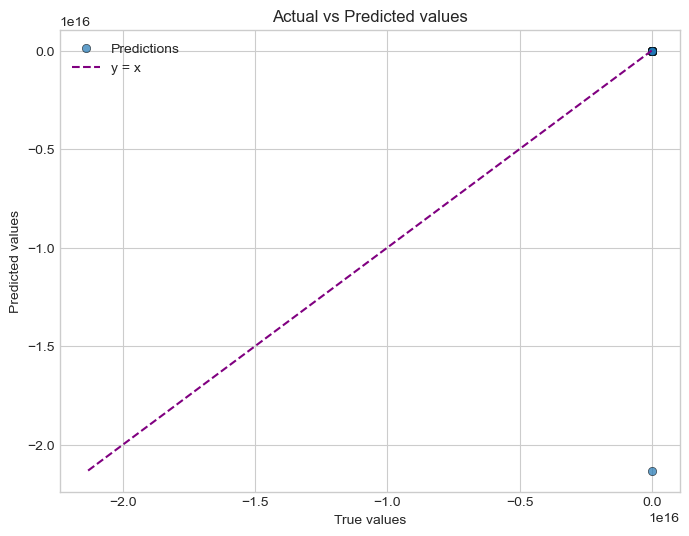

In [377]:
plot_actual_predicted(y_test_original_scale, prediction1_non_scaled)

This is not good, and the cause of this is the multi colinearity between the features (as indicated in the heatmap of the EDA)

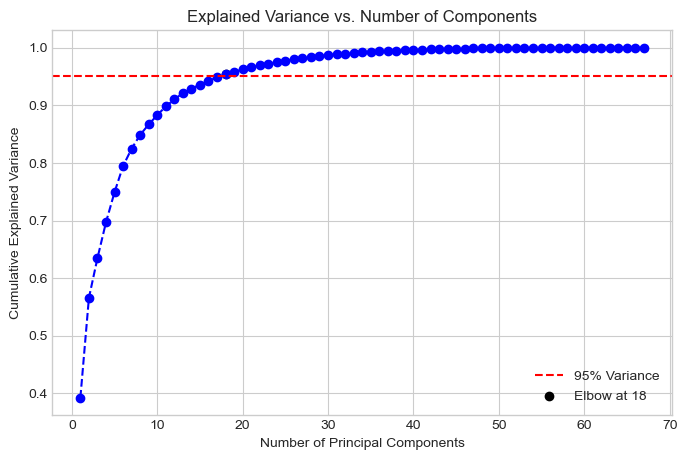

Optimal number of components: 18


In [378]:
pca = PCA()
X_pca = pca.fit_transform(X_train)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

#visualisation

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components")


plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance")


optimal_components = np.argmax(explained_variance >= 0.95) + 1
plt.scatter(optimal_components, explained_variance[optimal_components - 1], color='black', label=f"Elbow at {optimal_components}")
plt.legend()
plt.show()

print(f"Optimal number of components: {optimal_components}")


Applying the PCA

In [379]:
pca = PCA(n_components=18)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)

In [380]:
linear_regressor.fit(X_train_pca, y_train)
predicted2 = linear_regressor.predict(X_test_pca)

regression_report(predicted2, y_test)

       Regression performance report
   Mean squared error:  4.528 
   Mean absolute error: 1.644 
   Root mean squared error: 2.128 
   R2 score: -2.216


##### Cross validation

In [381]:
scores = cross_validate(linear_regressor, X_train_pca, y_train, cv=5, scoring='r2')
print(f"Training Mean R²: {scores['test_score'].mean():.3f}")

print(f"Test Mean R²:  {r2_score(y_test, predicted2):.3f}")

Training Mean R²: 0.809
Test Mean R²:  -2.216


There is an improvement, but there is a sign of underfitting.

* Getting the non scaled predictions

In [382]:
prediction2_non_scaled = scaler_y.inverse_transform(predicted2.reshape(-1, 1)).flatten()

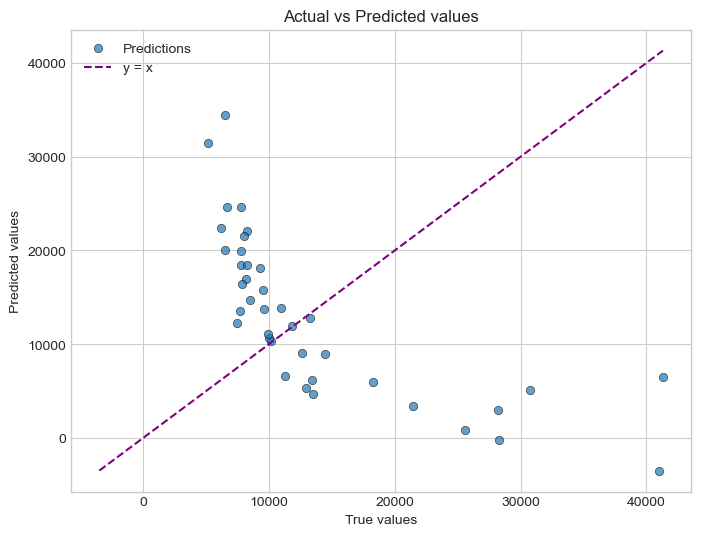

In [383]:
plot_actual_predicted(y_test_original_scale, prediction2_non_scaled)

#### Transforming the features

Training CV R²: 0.602
Test R²: 0.431
       Regression performance report
   Mean squared error:  46655806.884 
   Mean absolute error: 2986.522 
   Root mean squared error: 6830.506 
   R2 score: 0.431


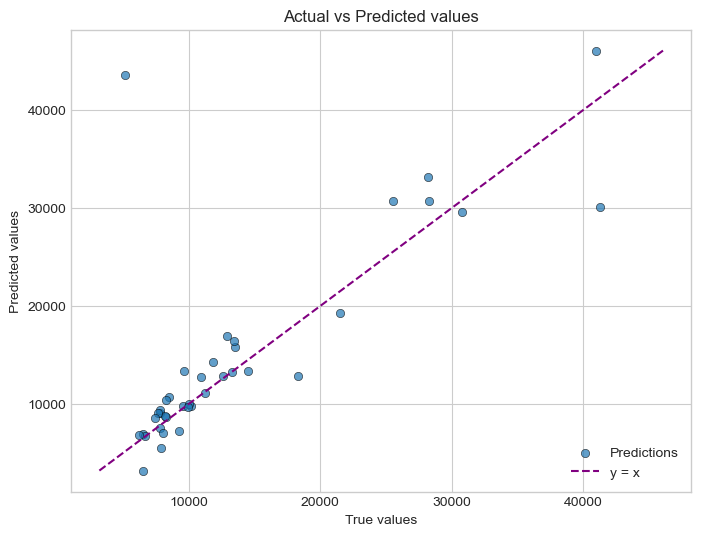

In [384]:
model = make_pipeline(
    PowerTransformer(),
    StandardScaler(),
    LinearRegression()
)

# cross-validate the training
train_scores = cross_validate(model, X_train_original_scale, y_train_original_scale, cv=5, scoring='r2')
print(f"Training CV R²: {train_scores['test_score'].mean():.3f}")


model.fit(X_train_original_scale, y_train_original_scale)  
test_r2 = model.score(X_test_original_scale, y_test_original_scale)
print(f"Test R²: {test_r2:.3f}")


predicted = model.predict(X_test_original_scale)
regression_report(predicted, y_test_original_scale)
predicted

plot_actual_predicted(y_test_original_scale, predicted)

### Using Regulization

Training CV R²: 0.881
Test R²: 0.820
       Regression performance report
   Mean squared error:  14778511.372 
   Mean absolute error: 2243.683 
   Root mean squared error: 3844.283 
   R2 score: 0.82


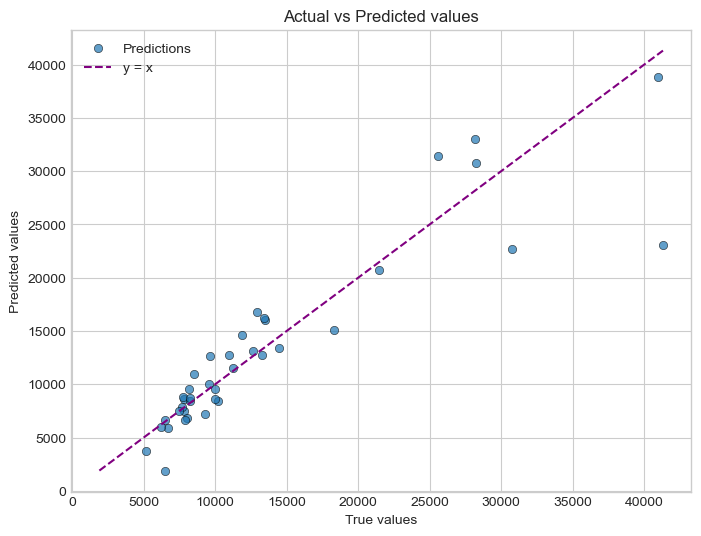

In [385]:
model = make_pipeline(
    PowerTransformer(),
    RobustScaler(),
    Ridge(alpha=1.0)  
)

# cross-validate the training
train_scores = cross_validate(model, X_train_original_scale, y_train_original_scale, cv=5, scoring='r2')
print(f"Training CV R²: {train_scores['test_score'].mean():.3f}")


model.fit(X_train_original_scale, y_train_original_scale)  
test_r2 = model.score(X_test_original_scale, y_test_original_scale)
print(f"Test R²: {test_r2:.3f}")


predicted = model.predict(X_test_original_scale)
regression_report(predicted, y_test_original_scale)


plot_actual_predicted(y_test_original_scale, predicted)

### Visualization

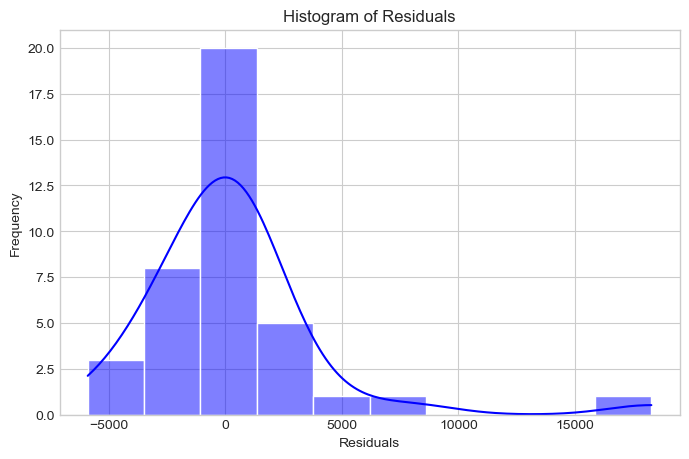

In [386]:
histogram_residuals(y_test_original_scale, predicted)

This histogram indicates that the residuals follow a normal distribution (but has a little right skew to it) which is a good sign since it shows that the model captures all systematic patterns leaving only the white noise.

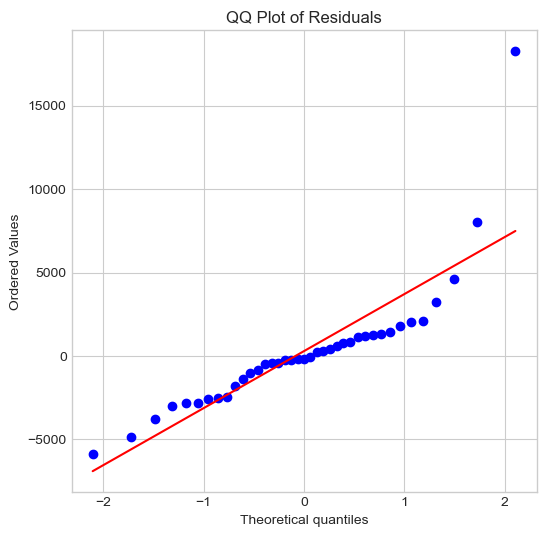

In [387]:
res = y_test_original_scale.to_numpy().flatten() - predicted.flatten()
plot_qq(res)

The qq plot shows that the residuals follow the straight line, which validates our assumption that the residuals are normally distributed.

### Comparaison between the predicted prices and the actual prices

In [388]:
y_test_arr = y_test_original_scale.to_numpy().flatten()
predicted_arr = predicted.flatten()

comparaison = pd.DataFrame({
    "Actual price: ":y_test_arr,
    "Predicted Price: ":predicted_arr
})

print(comparaison)

    Actual price:   Predicted Price: 
0          30760.0       22721.463770
1           9549.0        9989.998449
2          11850.0       14650.059877
3          28248.0       30747.163986
4           7799.0        7505.832095
5           7788.0        8658.265924
6           9258.0        7243.964698
7          10198.0        8397.306052
8           7775.0        8780.000037
9          13295.0       12721.669789
10          8238.0        8462.876127
11         18280.0       15062.483500
12          9988.0        9588.764400
13         40960.0       38879.969496
14          6488.0        6652.060792
15          5151.0        3721.377677
16         12629.0       13073.588509
17          8189.0        9574.220703
18          9960.0        8647.346004
19          8495.0       10975.528816
20         13499.0       16074.004715
21          8249.0        8740.459681
22          6479.0        1895.715144
23          6692.0        5880.565134
24         41315.0       23039.807960
25          

# Conclusion

* The linear regression model at first showed terrible prediction with negative R2 score, and this is because the features were collinear and had no linear relationship with the target.  

* After this, PCA was tried to lower the dimensionality thus delete the collinearity. However after the training and the cross validation the result showed overfitting with bad score. Which suggests that this approach is not suitable. 

* Finally, the approach that showed some improvement was transforming the features using the pipe line and the PowerTransformer transformation, that makes the data more linear.    
But in the end the approach that worked well with 82% R2 score is the Ridge regularization. Which means that for this type of data that shows non linearity the standard Linear Regression model doesn't work well, variation of this model along with the transformation of the features is the solution for better prediction.

_________________________

# Naive Bayes :
Naive Bayes is a probabilistic machine learning algorithm based on Bayes' Theorem. It is particularly useful for classification tasks and assumes that the features are independent of each other (hence "naive"). Despite this assumption, it often performs well in practice, especially for text classification and spam filtering.

# Initialize the Bayes Naive model

- . Why Gaussian Distribution?
Continuous Data: Gaussian Naive Bayes is specifically designed for continuous data. It assumes that the data for each feature is distributed according to a Gaussian (normal) distribution.
Simplicity: The Gaussian distribution is mathematically simple to work with, as it only requires calculating the mean and variance for each feature.
Common in Real-World Data: Many real-world datasets approximately follow a normal distribution, making the Gaussian assumption reasonable in practice.

- Functions :

In [67]:
def plot_residuals_vs_predicted(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')  
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Predicted Plot")
    plt.grid(True)
    plt.show()

- Naive Bayes Regressor Model :

- The GaussiannNB from scikit-learn is designed for classification tasks.
- We define our model GaussianNaiveBayesRegressor where variance is used to model the Gaussian (normal) distribution of the features for each class.

In [68]:
class GaussianNaiveBayesRegressor:
    def __init__(self, epsilon=1e-6):
        self.epsilon = epsilon
        self.class_means = None
        self.class_vars = None
        self.class_priors = None
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]
        
        self.class_means = np.zeros((n_classes, n_features))
        self.class_vars = np.zeros((n_classes, n_features))
        self.class_priors = np.zeros(n_classes)

        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            self.class_means[i, :] = X_c.mean(axis=0)
            self.class_vars[i, :] = np.var(X_c, axis=0) + self.epsilon 
            self.class_priors[i] = (X_c.shape[0] + self.epsilon) / (X.shape[0] + len(self.classes) * self.epsilon)

    def predict(self, X):

        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))

        for i, c in enumerate(self.classes):
            log_prior = np.log(self.class_priors[i])
            log_likelihood = -0.5 * np.sum(
                np.log(2. * np.pi * np.maximum(self.class_vars[i, :], self.epsilon)) +
                ((X - self.class_means[i, :]) ** 2) / np.maximum(self.class_vars[i, :], self.epsilon),
                axis=1
            )
            log_probs[:, i] = log_prior + log_likelihood

        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs) / np.exp(log_probs).sum(axis=1, keepdims=True)

        y_pred = np.zeros(n_samples)
        for i, c in enumerate(self.classes):
            y_pred += probs[:, i] * c

        return y_pred
    
    def get_params(self, deep=True):
        
        return {"epsilon": self.epsilon}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

- Train and evaluate the model

In [69]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [70]:
model = GaussianNaiveBayesRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_pred, y_test)


       Regression performance report
   Mean squared error:  0.838 
   Mean absolute error: 0.537 
   Root mean squared error: 0.916 
   R2 score: 0.405


* Let's turn the predictions to the original scale for better interpretation

In [71]:
y_pred_not_scaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

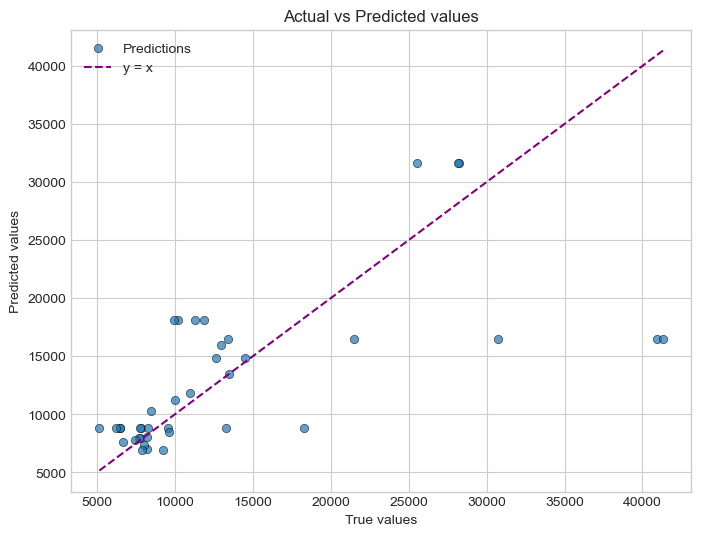

In [72]:
plot_actual_predicted(y_test_original_scale, y_pred_not_scaled)

- Analysis : we notice that the points do not follow the pattern the way we want so we will need some improvement

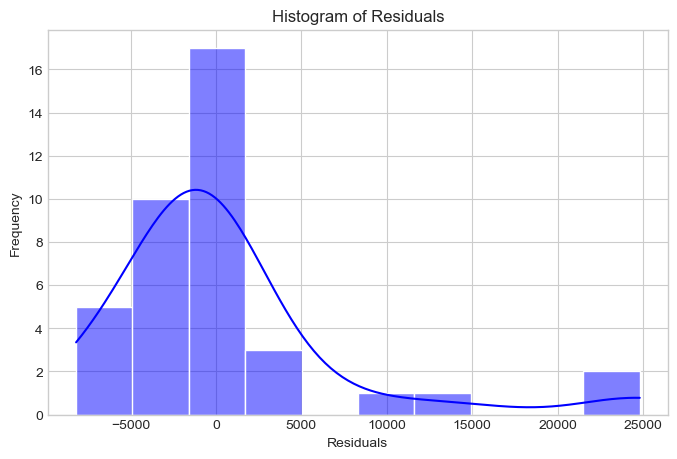

In [73]:
histogram_residuals(y_test_original_scale, y_pred_not_scaled)

- The residuals are right-skewed, indicating the model tends to underestimate some values, with moderate variance and a few outliers, suggesting potential improvements through transformation, feature scaling, or a more robust model.

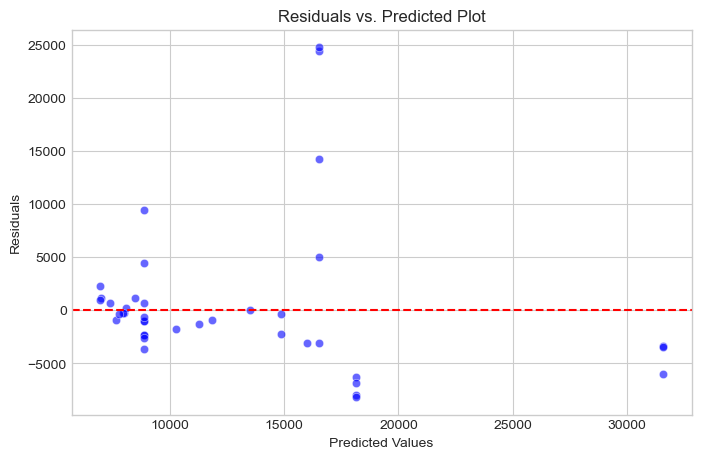

In [74]:
plot_residuals_vs_predicted(y_test_original_scale, y_pred_not_scaled)

- Residuals vs. Predicted Plot: Residuals show patterns, indicating model bias or underfitting.

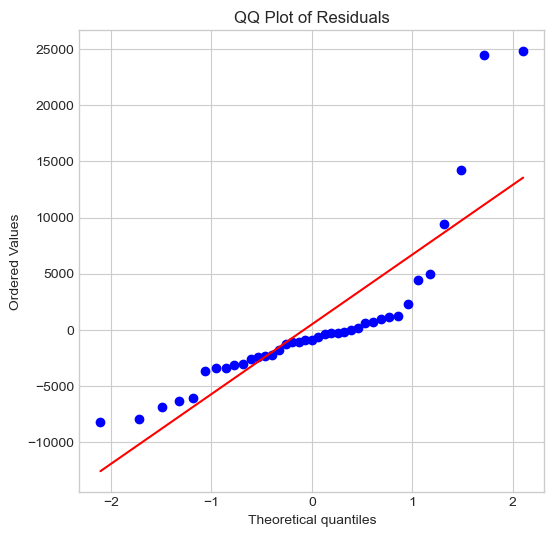

In [75]:
residuals = y_test_original_scale - y_pred_not_scaled
plot_qq(residuals)

Residuals deviate from normality

- Analyze the diffrent results :

According to the performance measures the model is not performing well because of the quite small R2 value and the relatively high value for the error measures.

We can also see that our model does follow the pattern we want but not with the amount we want so we it will need a bit of improvement


- Use hypermarameter tuning to improve the model by selecting the best epsilon value :

In [76]:
from skopt.space import Categorical

pipeline_bayes = make_pipeline(
    GaussianNaiveBayesRegressor()  
)

search_space = {
    'gaussiannaivebayesregressor__epsilon': Categorical([ 2e-3,3e-3,4e-3,5e-3,6e-3,7e-3,8e-3 ,9.4e-3]),
}

bayes_search = BayesSearchCV(
    pipeline_bayes, 
    search_space, 
    n_iter=20,  
    cv=5, 
    scoring="neg_mean_squared_error", 
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)

print(" Bayesian Search Best Parameters: ", bayes_search.best_params_)

best_model_bayes = bayes_search.best_estimator_

y_pred_bayes = best_model_bayes.predict(X_test)

regression_report(y_pred_bayes, y_test)

 Bayesian Search Best Parameters:  OrderedDict([('gaussiannaivebayesregressor__epsilon', 0.0094)])
       Regression performance report
   Mean squared error:  0.189 
   Mean absolute error: 0.275 
   Root mean squared error: 0.434 
   R2 score: 0.866


In [77]:
y_pred_bayes_not_scaled = scaler_y.inverse_transform(y_pred_bayes.reshape(-1, 1)).flatten()

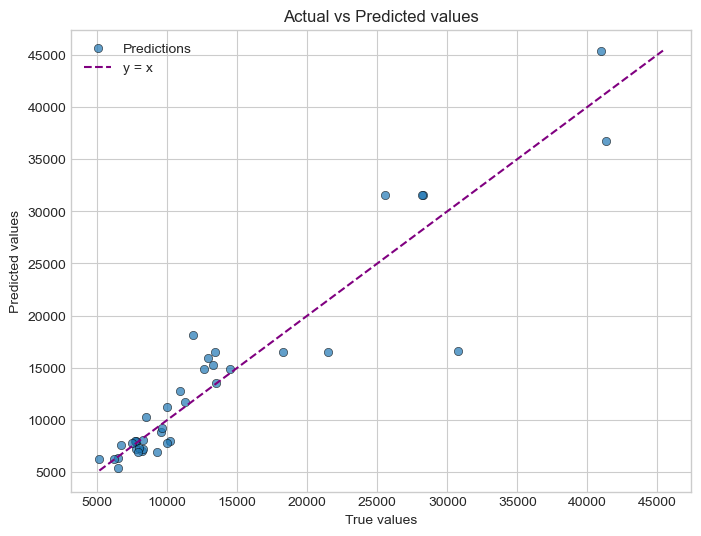

In [78]:
plot_actual_predicted(y_test_original_scale, y_pred_bayes_not_scaled)

 Predictions align well with the diagonal line, but some outliers deviate from the pattern

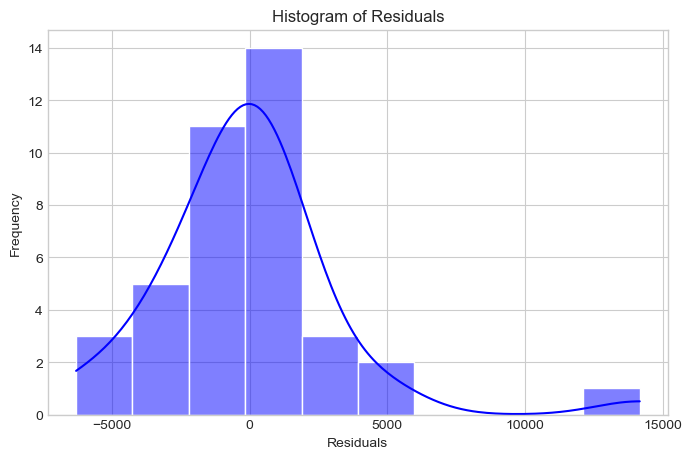

In [79]:
histogram_residuals(y_test_original_scale, y_pred_bayes_not_scaled)

 Residuals are roughly centered around zero, but the distribution is slightly skewed.

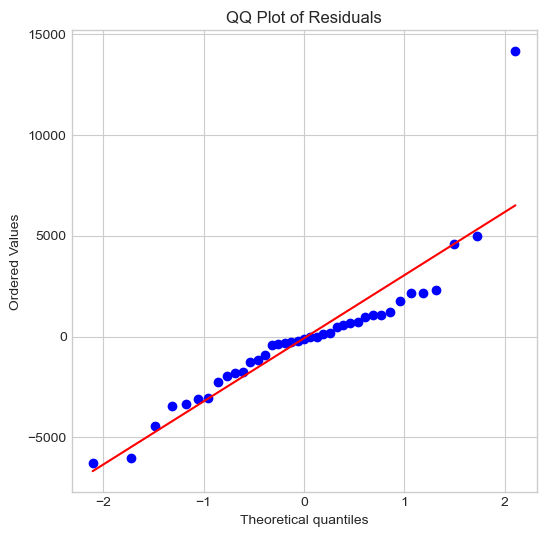

In [80]:
plot_qq(y_test_original_scale - y_pred_bayes_not_scaled)

Residuals mostly follow the red line, but slight deviations at the tails suggest minor non-normality.

- Analyzing the improvement results :
We can see that our model has significantly improved in terms of performance measures and capturing the patterns 

- Comparision between predictions and actual price values

In [82]:
actual = y_test_original_scale
pred = y_pred_bayes_not_scaled

comparaison = pd.DataFrame({
    "Actual price standardized: ":actual,
    "Predicted Price standardized: ":pred
})

print(comparaison)

    Actual price standardized:   Predicted Price standardized: 
0                       30760.0                    16595.204730
1                        9549.0                     8850.950869
2                       11850.0                    18150.000000
3                       28248.0                    31600.000000
4                        7799.0                     7243.274002
5                        7788.0                     7898.000000
6                        9258.0                     6938.000000
7                       10198.0                     8013.000000
8                        7775.0                     7995.000000
9                       13295.0                    15250.000000
10                       8238.0                     8058.000000
11                      18280.0                    16500.000000
12                       9988.0                    11248.000000
13                      40960.0                    45400.000000
14                       6488.0         

- Conclusion :
    - The overall Naive Bayes performance is good , with quite law error performance measures and a high R2 score.
    - The predictions comparisions are quite close with the presence of some outliers that we can see them present in our comparision.
    - Hyper paramter tuning helped in improving the model perfomance noticebally 

